This notebook is for analysis of the micro1 controlled experiment.

We have two pipelines which result in two datasets(AI and Manual). The first pipeline is those candidates who were prompted to complete an AI led interview. Only 6121 out of 25481 candidates completed the interview. The second pipeline is those candidates who were not prompted to complete an AI led interview but instead were sorted by an AI ranking system (not novel) and then screened by a human. 11298 candidates were ranked and the top candidates were selected for the manual screening by ah human.
1. AI pipeline
2. Manual pipeline

We have three datasets:
1. AI dataset
2. Manual (resume)screening dataset
3. Top candidates dataset: these are the top candidates from both the AI and manual datasets that were interviewed by a human.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:
AI_applicants_df = pd.read_csv("job_101(AI)_w_age_gender.csv")
manual_screening_applicants_df = pd.read_csv("job_110(Manual)_w_age_gender.csv")

ai_df_unique = AI_applicants_df.drop_duplicates(subset=['_client_job_id'], keep='first')
ai_df_unique.head()

,first_name,last_name,email_id,_client_job_id,country_code,job_application_id,years_of_exp,is_completed,vetting_creation_date,vetting_completed_date,is_deleted,status,developer_location,is_certified_developer,is_passed,education,gender,age
0,Lyuben,Tenekedzhiev,lyuben.tenekedjiev@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,2b85d400-3fd9-4747-af25-314bfdd9220c,4.7,1.0,2025-01-31 14:48:27,2025-01-31 15:31:05,0.0,active,United Arab Emirates,0.0,False,[],Male,-1


In [21]:
manual_screening_applicants_df = pd.read_csv("job_110(Manual)_w_age_gender.csv")
manual_df_unique = manual_screening_applicants_df.drop_duplicates(subset=['_client_job_id'], keep='first')
manual_df_unique.head()

,first_name,last_name,email_id,_client_job_id,country_code,job_application_id,years_of_experience,years_of_exp,is_completed,vetting_creation_date,vetting_completed_date,is_deleted,status,developer_location,is_certified_developer,is_passed,education,gender,age
0,Srijan,Rai,srijanrai61@gmail.com,d1e2b62f-4954-49c6-931c-ba76aa4741e1,IN,99bd9dac-7f44-4bbb-afca-776223ef0670,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"[{""major"": ""Computer Science"", ""degree"": ""Bach...",Male,26


In [22]:
AI_applicants_df.shape[0]


25543

In [23]:
manual_screening_applicants_df.shape[0]

11295

In [24]:
# Count the number of rows with duplicate email_id values
# First, identify which email_ids appear more than once
duplicate_email_ids = AI_applicants_df['email_id'].value_counts()
duplicate_email_ids = duplicate_email_ids[duplicate_email_ids > 1]

# Then, count the total number of rows that have these duplicate email_ids
rows_with_duplicate_emails = AI_applicants_df[AI_applicants_df['email_id'].isin(duplicate_email_ids.index)].shape[0]
rows_with_duplicate_emails




0

In [25]:
# Count the number of rows with duplicate email_id values
# First, identify which email_ids appear more than once
duplicate_email_ids = manual_screening_applicants_df['email_id'].value_counts()
duplicate_email_ids = duplicate_email_ids[duplicate_email_ids > 1]

# Then, count the total number of rows that have these duplicate email_ids
rows_with_duplicate_emails = manual_screening_applicants_df[manual_screening_applicants_df['email_id'].isin(duplicate_email_ids.index)].shape[0]
rows_with_duplicate_emails

0

In [26]:
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")
top_candidates_interviewed.shape[0]


85

In [27]:
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")
filtered_rows = top_candidates_interviewed[(top_candidates_interviewed['Interview Type'] == 'AI + Human Interview') & (top_candidates_interviewed['Result'] == 'Fail')]
filtered_rows.shape[0]

12

In [28]:
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")
filtered_rows = top_candidates_interviewed[(top_candidates_interviewed['Interview Type'] == 'AI + Human Interview') & (top_candidates_interviewed['Result'] == 'Pass')]
filtered_rows.shape[0]

19

From the above two cells we can see that out of those who did an Ai interview and then procedded to a human interview, 19/31(61.29%) passed and 12/31(38.71%) failed.

In [29]:
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")
filtered_rows = top_candidates_interviewed[(top_candidates_interviewed['Interview Type'] == 'only Human interview') & (top_candidates_interviewed['Result'] == 'Pass')]
filtered_rows.shape[0]

13

In [30]:
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")
filtered_rows = top_candidates_interviewed[(top_candidates_interviewed['Interview Type'] == 'only Human interview') & (top_candidates_interviewed['Result'] == 'Fail')]
filtered_rows.shape[0]

35

From the above two cells we can see that out of those who did an only a Human led interview, 13/48(27%) passed and 35/48 failed.

### Demographics of the applicants who succeeded and failed the human interview

Gender distribution of candidates who passed:
Gender
Male      90.322581
Female     9.677419
Name: count, dtype: float64


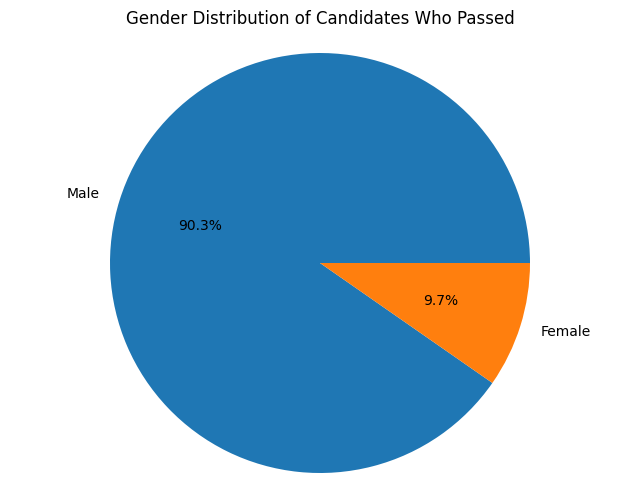

In [31]:
# Load the data
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")

# Filter for passed candidates
passed_candidates = top_candidates_interviewed[top_candidates_interviewed['Result'] == 'Pass']

# Count by gender
gender_counts = passed_candidates['Gender'].value_counts()

# Calculate percentages
gender_percentages = gender_counts / gender_counts.sum() * 100

# Display the results
print("Gender distribution of candidates who passed:")
print(gender_percentages)

# Optional: Create a pie chart visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(gender_percentages, labels=gender_percentages.index, autopct='%1.1f%%')
plt.title('Gender Distribution of Candidates Who Passed')
plt.axis('equal')
plt.show()


Pass rates by gender:
Result  Pass  Fail  Total  Pass Rate
Gender                              
Female     3     7     10       30.0
Male      28    40     70       40.0


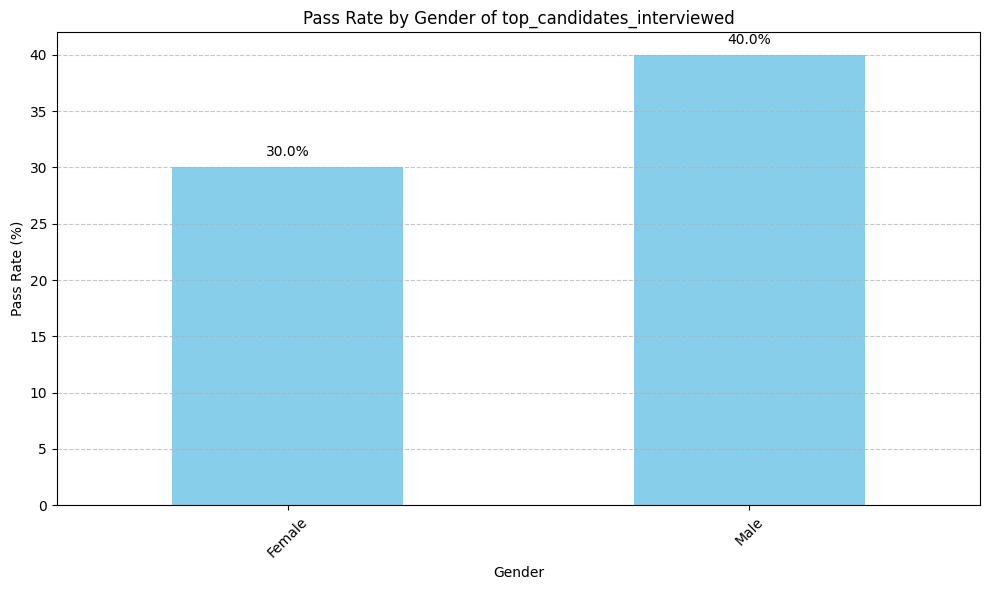


Statistical Significance Test:
Chi-square value: 0.1078
p-value: 0.7427
Degrees of freedom: 1
The difference in pass rates between genders is not statistically significant (p > 0.05).


In [32]:
# Load the data (if not already loaded)
if 'top_candidates_interviewed' not in locals():
    top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")

# Group by gender and result, then count
gender_result_counts = top_candidates_interviewed.groupby(['Gender', 'Result']).size().unstack(fill_value=0)

# Calculate pass rates for each gender
gender_result_counts['Total'] = gender_result_counts.sum(axis=1)
gender_result_counts['Pass Rate'] = gender_result_counts['Pass'] / gender_result_counts['Total'] * 100

# Display the results
print("Pass rates by gender:")
print(gender_result_counts[['Pass', 'Fail', 'Total', 'Pass Rate']])

# Create a bar chart visualization
plt.figure(figsize=(10, 6))
gender_result_counts['Pass Rate'].plot(kind='bar', color='skyblue')
plt.title('Pass Rate by Gender of top_candidates_interviewed')
plt.xlabel('Gender')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of each bar
for i, rate in enumerate(gender_result_counts['Pass Rate']):
    plt.text(i, rate + 1, f'{rate:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Statistical significance test
import scipy.stats as stats

# Create a contingency table for chi-square test
contingency_table = gender_result_counts[['Pass', 'Fail']]

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\nStatistical Significance Test:")
print(f"Chi-square value: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"The difference in pass rates between genders is statistically significant (p < {alpha}).")
else:
    print(f"The difference in pass rates between genders is not statistically significant (p > {alpha}).")


In [33]:
top_candidates_interviewed
# Filter candidates who passed
passed_candidates = top_candidates_interviewed[top_candidates_interviewed['Result'] == 'Pass']

# Calculate statistics for passed candidates
print("\nStatistics for Passed Candidates:")

# Experience statistics
exp_mean = passed_candidates['Experience'].mean()
exp_median = passed_candidates['Experience'].median()
exp_std = passed_candidates['Experience'].std()

print(f"\nExperience Statistics:")
print(f"Mean: {exp_mean:.2f} years")
print(f"Median: {exp_median:.2f} years")
print(f"Standard Deviation: {exp_std:.2f} years")

# Age statistics (if available)
if 'Age' in passed_candidates.columns and passed_candidates['Age'].notna().any():
    age_mean = passed_candidates['Age'].mean()
    age_median = passed_candidates['Age'].median()
    age_std = passed_candidates['Age'].std()
    
    print(f"\nAge Statistics:")
    print(f"Mean: {age_mean:.2f} years")
    print(f"Median: {age_median:.2f} years")
    print(f"Standard Deviation: {age_std:.2f} years")

# Communication score statistics (if available)
if 'Communication' in passed_candidates.columns and passed_candidates['Communication'].notna().any():
    # Convert communication ratings to numeric if needed
    comm_counts = passed_candidates['Communication'].value_counts()
    print(f"\nCommunication Level Distribution:")
    print(comm_counts)

# Proctoring score statistics (if available)
if 'Proctoring' in passed_candidates.columns and passed_candidates['Proctoring'].notna().any():
    # Remove % sign and convert to numeric
    passed_candidates['Proctoring_Numeric'] = passed_candidates['Proctoring'].str.rstrip('%').astype(float)
    
    proct_mean = passed_candidates['Proctoring_Numeric'].mean()
    proct_median = passed_candidates['Proctoring_Numeric'].median()
    proct_std = passed_candidates['Proctoring_Numeric'].std()
    
    print(f"\nProctoring Score Statistics:")
    print(f"Mean: {proct_mean:.2f}%")
    print(f"Median: {proct_median:.2f}%")
    print(f"Standard Deviation: {proct_std:.2f}%")



Statistics for Passed Candidates:

Experience Statistics:
Mean: 6.15 years
Median: 5.00 years
Standard Deviation: 3.18 years

Communication Level Distribution:
Communication
B2 (Good)         5
C1 (Excellent)    1
Name: count, dtype: int64

Proctoring Score Statistics:
Mean: 76.83%
Median: 77.00%
Standard Deviation: 7.33%


/var/folders/55/zxlszwyx6ts_bpf6cjjywywr0000gn/T/ipykernel_45907/2211590159.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_candidates['Proctoring_Numeric'] = passed_candidates['Proctoring'].str.rstrip('%').astype(float)


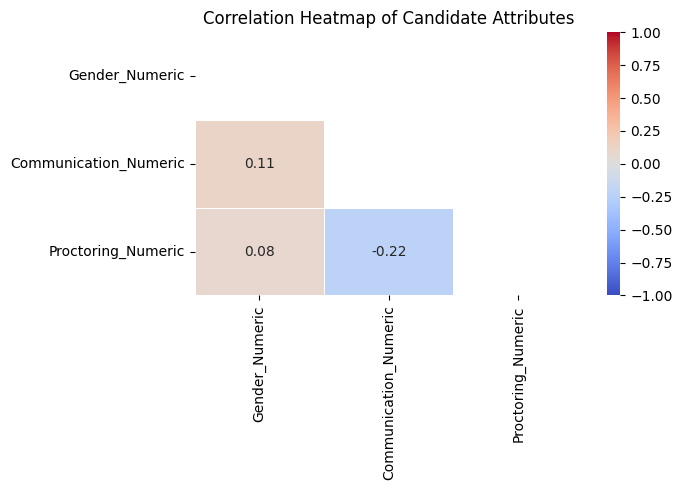

In [34]:
# Create a correlation heatmap for the specified columns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Prepare the data for correlation analysis
# First, ensure all columns are in the right format
corr_data = top_candidates_interviewed.copy()

# Convert gender to numeric (1 for Male, 0 for Female)
if 'Gender' in corr_data.columns:
    corr_data['Gender_Numeric'] = corr_data['Gender'].map({'Male': 1, 'Female': 0})

# Convert communication levels to numeric values
if 'Communication' in corr_data.columns:
    comm_mapping = {
        'C1 (Excellent)': 5, 
        'B2 (Good)': 4, 
        'B1 (Intermediate)': 3, 
        'A2 (Basic)': 2, 
        'A1 (Beginner)': 1
    }
    corr_data['Communication_Numeric'] = corr_data['Communication'].map(comm_mapping)

# Convert Proctoring to numeric by removing % sign
if 'Proctoring' in corr_data.columns:
    corr_data['Proctoring_Numeric'] = corr_data['Proctoring'].str.rstrip('%').astype(float)

# Select columns for correlation based on the specified requirements
columns_to_correlate = []
for col in ['years_of_exp', 'is_passed', 'age', 'Gender_Numeric', 'Communication_Numeric', 'Proctoring_Numeric']:
    if col in corr_data.columns:
        columns_to_correlate.append(col)

# Calculate correlation matrix
correlation_matrix = corr_data[columns_to_correlate].corr()

# Create the heatmap with smaller figure size
plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            mask=mask,
            vmin=-1, 
            vmax=1)
plt.title('Correlation Heatmap of Candidate Attributes')
plt.tight_layout()
plt.show()


In [36]:
AI_applicants_df
manual_screening_applicants_df
top_candidates_interviewed
# Merge all three datasets using email_id as the key
# Using outer merge to ensure we don't lose any rows

# First merge AI_applicants_df with manual_screening_applicants_df
merged_df = pd.merge(
    AI_applicants_df,
    manual_screening_applicants_df,
    on='email_id',
    how='outer',
    suffixes=('_ai', '_manual')
)

# Then merge the result with top_candidates_interviewed
final_merged_df = pd.merge(
    merged_df,
    top_candidates_interviewed,
    on='email_id',
    how='outer',
    suffixes=('', '_interview')
)

# Check the shape of the original and merged dataframes
print(f"AI_applicants_df shape: {AI_applicants_df.shape}")
print(f"manual_screening_applicants_df shape: {manual_screening_applicants_df.shape}")
print(f"top_candidates_interviewed shape: {top_candidates_interviewed.shape}")
print(f"Final merged dataframe shape: {final_merged_df.shape}")

# Display the first few rows of the merged dataframe
final_merged_df


AI_applicants_df shape: (25543, 18)
manual_screening_applicants_df shape: (11295, 19)
top_candidates_interviewed shape: (85, 21)
Final merged dataframe shape: (34509, 56)


,first_name_ai,last_name_ai,email_id,_client_job_id_ai,country_code_ai,job_application_id_ai,years_of_exp_ai,is_completed_ai,vetting_creation_date_ai,vetting_completed_date_ai,...,Column 20,Column 19,Country,React,JavaScript,"HTML,CSS",Coding Exercise,Communication,Proctoring,Experience
0,Lyuben,Tenekedzhiev,lyuben.tenekedjiev@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,2b85d400-3fd9-4747-af25-314bfdd9220c,4.7,1.0,2025-01-31 14:48:27,2025-01-31 15:31:05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nils,Schönwald,jobs@schoen.world,7ab84d91-00ca-460f-ac82-ccad63fb306c,DE,009ebd42-bb46-4666-a0a1-0c988b6adcaf,13.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Adrian,SAFKO,adrian.safko@hotovo.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,SK,cce06f38-ac85-4214-b615-ef98266e8111,14.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jerold,Twum Adjei-Ampofo,jjaampofo@yahoo.co.uk,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,9fd030ba-6411-425d-b1b3-00f43bccca63,10.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Helia,Valizadeh,heliiavalizadeh@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,DE,b539f958-3563-4979-9911-4bdadc6168eb,3.8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34504,NaN,NaN,heerak.jhp@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Experienced,Experienced,Experienced,Senior,B2 (Good),68%,4.0
34505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Poland,Experienced,Junior,Junior,Junior,B2 (Good),78%,5.0
34506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,India,Experienced,Junior,Junior,Senior,B2 (Good),74%,2.0
34507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


In [37]:
# Count the number of unique email_id in final_merged_df
unique_email_count = final_merged_df['email_id'].nunique()
print(f"Number of unique email_id in final_merged_df: {unique_email_count}")


Number of unique email_id in final_merged_df: 34504


In [46]:

# check to see how many of the emails in the top candidates dataset are in the AI and manual datasets
top_candidates_interviewed['email_id'].isin(AI_applicants_df['email_id']).sum()
# top_candidates_interviewed['email_id'].isin(manual_screening_applicants_df['email_id']).sum()





45

### The below shows there are duplicates in the AI and manual datasets

In [48]:
# check to see how many emails in AI_applicants_df are in the manual_screening_applicants_df
AI_applicants_df['email_id'].isin(manual_screening_applicants_df['email_id']).sum()


2335